## Final Project Analysis

This notebook covers three control systems that bring together the main topics
from TP1 to TP5, and introduces one new method from CM6.




### Course recap: what each TP covered

- TP1: State-space modeling. Given a physical system, write the ODE, 
  define state variables, and build A, B, C, D matrices. Simulated with odeint.

- TP2: PID control. Closed-loop tracking, continuous PID design and tuning.
  CM2 also introduces the digital PID in velocity form.

- TP3: Controllability and Observability. Kalman rank test on [B AB ...] 
  and [C CA ...]^T. Tells us whether we can control/observe all state modes.

- TP4: Full-state feedback. Pole placement with scipy place_poles. 
  Cart-pole system first appeared here.

- TP5: State observers and LQR. Luenberger observer, Kalman filter design,
  LQR for optimal Q/R-weighted gain. Discretization via ZOH.

### EX1 — Mass-Spring-Damper

The same system as TP1 and TP2, but pushed further.

Tasks done here that go beyond TP1-2:
- Controllability check before designing any controller
- Both continuous and discrete implementations of PID and FSF
- FSF with an integral term added to the augmented state (solves SSE)
- Side-by-side performance comparison with metrics

### EX2 — Quadruple-Tank

A MIMO nonlinear system. Uses linearization from TP1 and Kalman rank tests 
from TP3, but on a 4-state 2-input 2-output system — more complex than all TPs.

New here:
- Linearization of a 4-state nonlinear system at a given operating point
- Controllability/observability analysis under actuator failure
- Changing the output matrix C and checking how observability changes

### EX3 — Inverted Pendulum on Cart

The same cart-pole from TP4 and TP5, taken all the way to MPC.

Steps follow the full design chain:
1. Nonlinear model → linearization (TP1/TP2)
2. Controllability check + pole placement (TP3/TP4)
3. Partial output measurement, observability check (TP3/TP5)
4. LQR observer + controller (TP5)
5. MPC with input and state constraints — introduced in CM6, new to this project

## EX 1:  Mass-spring damper system


Let us consider a mass-spring-damper system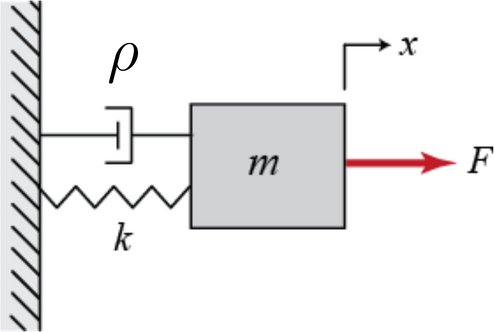

With the following system parameters:

      mass  m = 1.0 kg

      spring constant k = 5.0 N/m

      damping constant $\rho$ = 2 Ns/m

The state space model of the system is the following:

$$\dot x = Ax + Bu$$
$$ y = Cx$$

where
state vector $x = (p,v)$ (p - position, v - velocity), and state and control matrices are the following:
$$ A = \begin{pmatrix} 0&1\\ -\frac{k}{m}&-\frac{\rho}{m}\end{pmatrix},\ B = \begin{pmatrix} 0\\ \frac{1}{m} 
\end{pmatrix}$$

Addtional Info : postion y ref = 1 , C = [0,1]
## TODO
1. Is the system controllable?
2. Design a PID controller that ensures that the position of the closed-loop system tracks the constant reference $y_{ref}(t) = 1.$ Plot the trajectory of the closed-loop system, starting from $x = (0,0).$ Tune PID to ensure that rising time < 10s, overshoot < 10%, Steady-state error < 2%.  
3. Design a full-state feedback controller with an integral term $u = -Kx + k_z\int_0^t(y_{ref}(\tau) - p(\tau))\,d\tau$ that ensures that the position of the closed-loop system tracks the constant reference $y_{ref}(t) = 1.$  Plot the trajectory of the closed-loop system, starting from $x = (0,0).$ Chose eigenvalues properly, to ensure that rising time < 10s, overshoot < 10%, Steady-state error < 2%.  
4. Compare the performance of PID and full-state feedback controllers. What can you say? 

Let us now work with a discretized version of the system.

5. Disretise the system with sampling time T = 0.1s
6. Design a discrete version of the PID controller that ensures that the position of the closed-loop system tracks the constant reference $y_{ref,k} = 1.$ Plot the trajectory of the closed-loop system, starting from $x = (0,0).$ Tune PID to ensure that rising time < 10s, overshoot < 10%, Steady-state error < 2%.  
7. Design a full-state feedback controller with an integral term $u_k = - Kx_k + k_z\sum_{i=0}^k(y_{ref, i} - p_i)$ that ensures that the position of the closed-loop system tracks the constant reference $y_{ref,k} = 1.$  Plot the trajectory of the closed-loop system, starting from $x = (0,0).$ Chose eigenvalues properly to ensure that rising time < 10s, overshoot < 10%, Steady-state error < 2%.  
8. Compare the performance of PID and full-state feedback controllers. What can you say?


## EX1: Mass-Spring-Damper System

We consider a mass-spring-damper system with:
- mass $m = 1.0$ kg, spring constant $k = 5.0$ N/m, damping $\rho = 2.0$ Ns/m

**State-space representation** with state $x = [x_1, x_2]^T = [\text{position}, \text{velocity}]^T$:

$$\dot{x} = Ax + Bu, \quad y = Cx$$

$$A = \begin{pmatrix} 0 & 1 \\ -k/m & -\rho/m \end{pmatrix}, \quad
B = \begin{pmatrix} 0 \\ 1/m \end{pmatrix}, \quad
C = \begin{pmatrix} 1 & 0 \end{pmatrix}$$

**Tasks:** Controllability → Continuous PID → Discrete PID → Continuous FSF+Integral → Discrete FSF+Integral → Comparison

**Performance specs:** Rising time $T_r < 10$ s, Overshoot $< 10\%$, Steady-state error $< 2\%$


In [39]:
# --- Block 1: Imports and system parameters ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.signal import place_poles, cont2discrete
import control

# System parameters
m   = 1.0   # mass [kg]
k   = 5.0   # spring constant [N/m]
rho = 2.0   # damping coefficient [Ns/m]

# Reference and simulation settings
y_ref = 1.0          # position reference [m]
x0    = [0.0, 0.0]   # initial state [position, velocity]
T_end = 30.0         # simulation end time [s]

# Continuous-time simulation step
dt = 0.01
t  = np.arange(0, T_end, dt)

# Discrete sampling time
T_s   = 0.1
t_d   = np.arange(0, T_end, T_s)
N     = len(t_d)

print(f"System: m={m} kg, k={k} N/m, rho={rho} Ns/m")
print(f"Reference: y_ref = {y_ref} m, Sampling time: T_s = {T_s} s")


System: m=1.0 kg, k=5.0 N/m, rho=2.0 Ns/m
Reference: y_ref = 1.0 m, Sampling time: T_s = 0.1 s


### State-Space Model + Open-Loop Analysis

A =
 [[ 0.  1.]
 [-5. -2.]]
B =
 [[0.]
 [1.]]
C =
 [[1 0]]

Open-loop eigenvalues: [-1.+2.j -1.-2.j]
Open-loop system: STABLE


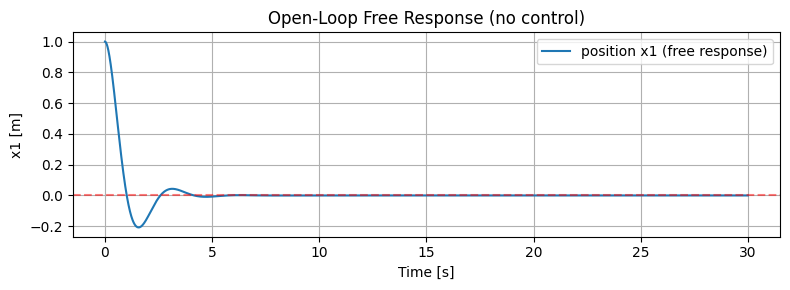

In [40]:
# --- Block 2: Build state-space matrices and check open-loop stability ---

A = np.array([[0,      1     ],
              [-k/m,  -rho/m ]])

B = np.array([[0  ],
              [1/m]])

C = np.array([[1, 0]])

D = np.array([[0]])

print("A =\n", A)
print("B =\n", B)
print("C =\n", C)

# Open-loop eigenvalues
eigs = np.linalg.eigvals(A)
print(f"\nOpen-loop eigenvalues: {eigs}")
print("Open-loop system:", "STABLE" if all(np.real(eigs) < 0) else "UNSTABLE")

# Quick open-loop step response (no input, just free decay from x0=[1,0])
def open_loop(x, t):
    return A @ x  # no control input, u=0

sol_ol = odeint(open_loop, [1.0, 0.0], t)
plt.figure(figsize=(8, 3))
plt.plot(t, sol_ol[:, 0], label='position x1 (free response)')
plt.axhline(0, color='r', linestyle='--', alpha=0.5)
plt.xlabel('Time [s]'); plt.ylabel('x1 [m]')
plt.title('Open-Loop Free Response (no control)')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


### Task 1 – Controllability Analysis

The **controllability matrix** for a system of order $n$ is:

$$\mathcal{M}_c = \begin{bmatrix} B & AB & A^2B & \cdots & A^{n-1}B \end{bmatrix}$$

The system is **fully controllable** if and only if $\text{rank}(\mathcal{M}_c) = n$.

For our 2nd-order system: $n=2$, so $\mathcal{M}_c = [B \;\; AB]$.


In [41]:
# --- Block 3: Controllability analysis (Kalman rank test) ---

n = A.shape[0]

# Build controllability matrix column by column
Mc = np.hstack([np.linalg.matrix_power(A, i) @ B for i in range(n)])

rank_Mc = np.linalg.matrix_rank(Mc)

print("Controllability matrix Mc = [B | AB]:")
print(Mc)
print(f"\nRank of Mc : {rank_Mc}")
print(f"System order n : {n}")
print("\n=> System is Controllable" if rank_Mc == n else "\n=> System is Not controllable")


Controllability matrix Mc = [B | AB]:
[[ 0.  1.]
 [ 1. -2.]]

Rank of Mc : 2
System order n : 2

=> System is Controllable


### Task 2 – Continuous-Time PID Controller

The PID control law:
$$u(t) = K_p \, e(t) + K_i \int_0^t e(\tau)\,d\tau + K_d \, \dot{e}(t)$$

where $e(t) = y_{ref} - y(t)$. Since $y = x_1$, we have $\dot{e} = -\dot{x}_1 = -x_2$.

We introduce an **integral state** $x_i$ with $\dot{x}_i = e(t)$ to simulate this in ODE form.

Gains are chosen to achieve the required performance specification.


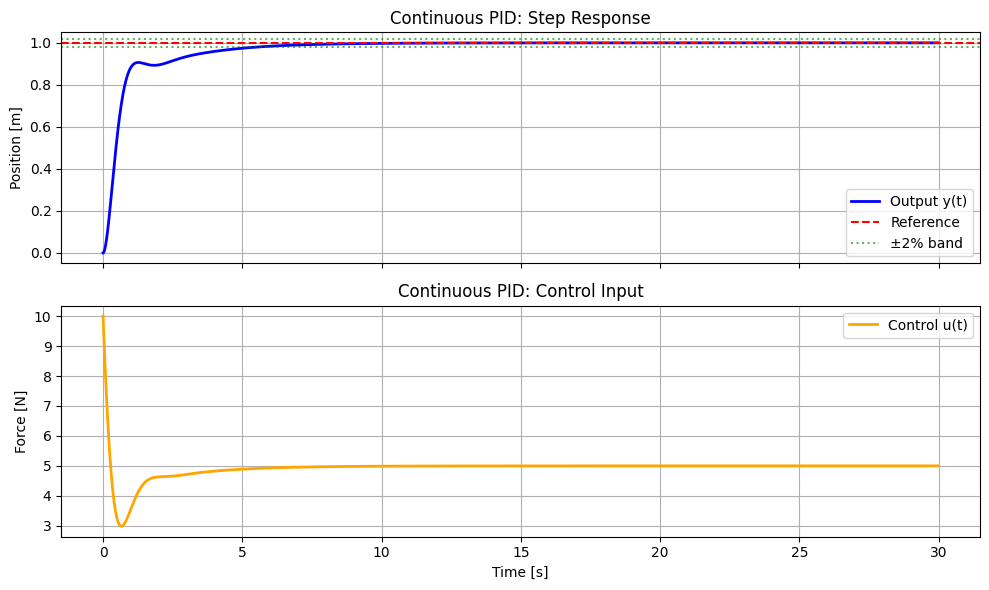

Continuous PID Performance:
  Rising Time        : 1.11 s  (spec < 10 s)
  Overshoot          : 0.00%  (spec < 10%)
  Steady-state Error : 0.0001%  (spec < 2%)


In [42]:
# --- Block 4: Continuous-time PID controller ---

# PID gains (tuned to meet specs: Tr < 10s, OS < 10%, SSE < 2%)
Kp_c = 10.0
Ki_c = 6.0
Kd_c = 3.0

def closed_loop_pid_cont(state, t, Kp, Ki, Kd, y_ref):
    """
    Augmented state: [x1, x2, xi]
    xi = integral of error, xi_dot = e = y_ref - x1
    """
    x1, x2, xi = state
    e    = y_ref - x1     # position error
    de   = -x2            # derivative of error = -velocity (since y=x1)
    u    = Kp*e + Ki*xi + Kd*de  # PID control law

    x1_dot = x2
    x2_dot = (-k*x1 - rho*x2 + u) / m  # Newton's law
    xi_dot = e
    return [x1_dot, x2_dot, xi_dot]

x0_aug = [x0[0], x0[1], 0.0]   # augmented initial state with xi(0)=0
sol_pid_c = odeint(closed_loop_pid_cont, x0_aug, t, args=(Kp_c, Ki_c, Kd_c, y_ref))

y_pid_c = sol_pid_c[:, 0]

# Reconstruct control input for plotting
u_pid_c = [Kp_c*(y_ref - s[0]) + Ki_c*s[2] + Kd_c*(-s[1]) for s in sol_pid_c]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax1.plot(t, y_pid_c, 'b', lw=2, label='Output y(t)')
ax1.axhline(y_ref, color='r', ls='--', label='Reference')
ax1.axhline(y_ref*1.02, color='g', ls=':', alpha=0.6, label='±2% band')
ax1.axhline(y_ref*0.98, color='g', ls=':', alpha=0.6)
ax1.set_ylabel('Position [m]'); ax1.set_title('Continuous PID: Step Response')
ax1.legend(); ax1.grid(True)

ax2.plot(t, u_pid_c, 'orange', lw=2, label='Control u(t)')
ax2.set_xlabel('Time [s]'); ax2.set_ylabel('Force [N]')
ax2.set_title('Continuous PID: Control Input')
ax2.legend(); ax2.grid(True)
plt.tight_layout(); plt.show()

# Performance metrics
def perf_metrics(t, y, y_ref):
    # Rising time: time to first reach 90% of reference
    idx_rise = np.where(y >= 0.9 * y_ref)[0]
    Tr = t[idx_rise[0]] if len(idx_rise) > 0 else float('inf')
    # Overshoot
    OS = max(0, (max(y) - y_ref) / y_ref * 100)
    # Steady-state error (average of last 20% of simulation)
    SSE = abs(np.mean(y[int(0.8*len(y)):]) - y_ref) / y_ref * 100
    return Tr, OS, SSE

Tr, OS, SSE = perf_metrics(t, y_pid_c, y_ref)
print(f"Continuous PID Performance:")
print(f"  Rising Time        : {Tr:.2f} s  (spec < 10 s)")
print(f"  Overshoot          : {OS:.2f}%  (spec < 10%)")
print(f"  Steady-state Error : {SSE:.4f}%  (spec < 2%)")


### Task 2 (cont.) – Discrete-Time PID Controller

Using the **backward Euler** discretization with sampling period $T_s = 0.1$ s:

$$u[k] = K_p \, e[k] + K_i \, T_s \sum_{j=0}^{k} e[j] + K_d \, \frac{e[k] - e[k-1]}{T_s}$$


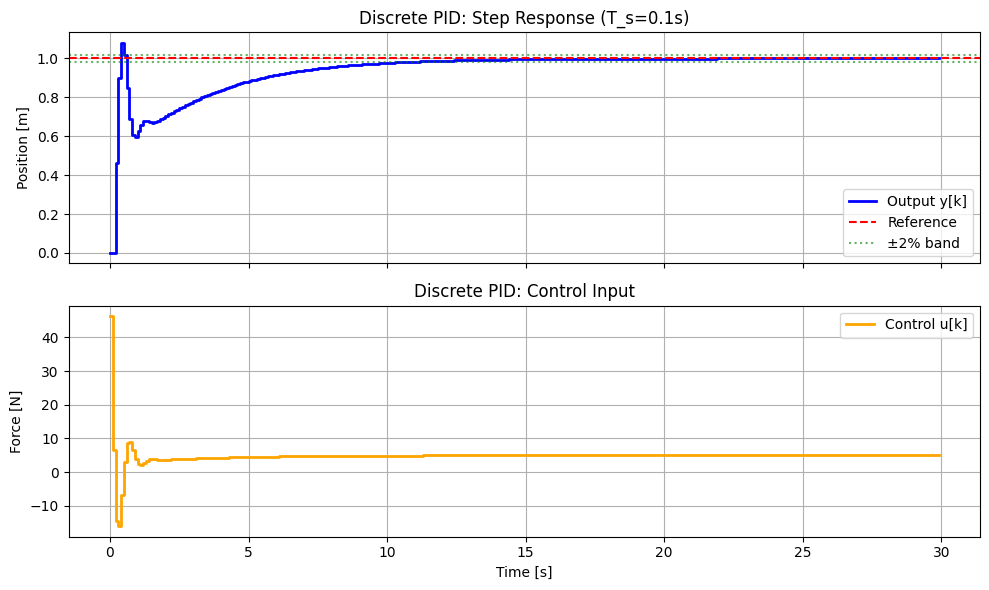

Discrete PID Performance (T_s = 0.1 s):
  Rising Time        : 0.40 s  (spec < 10 s)
  Overshoot          : 8.00%  (spec < 10%)
  Steady-state Error : 0.0114%  (spec < 2%)


In [43]:
# --- Block 5: Discrete-time PID controller (backward Euler) ---
# start with same gains, re-tune later
# Kp_d = Kp_c   
# Ki_d = Ki_c
# Kd_d = Kd_c

# tuned
Kp_d = 6
Ki_d = 3
Kd_d = 4   # small Kd to avoid overshoot from discrete derivative

# Storage
y_pid_d = np.zeros(N)
u_pid_d = np.zeros(N)
x_d     = np.array(x0, dtype=float)

# History of errors needed for velocity form
e_prev2 = 0.0   # e[k-2]
e_prev1 = 0.0   # e[k-1]
u_prev  = 0.0   # u[k-1]

for k in range(N):
    y_val   = x_d[0]          # measured position
    e       = y_ref - y_val   # current error

    # Velocity form: compute increment delta_u
    delta_u = (Kp_d * (e - e_prev1)
             + Ki_d * T_s * e
             + Kd_d / T_s * (e - 2*e_prev1 + e_prev2))

    u = u_prev + delta_u       # accumulate control output

    y_pid_d[k] = y_val
    u_pid_d[k] = u

    # Euler integration of plant
    x_dot = A @ x_d + B.flatten() * u
    x_d   = x_d + T_s * x_dot

    # Shift error history
    e_prev2 = e_prev1
    e_prev1 = e
    u_prev  = u


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax1.step(t_d, y_pid_d, 'b', where='post', lw=2, label='Output y[k]')
ax1.axhline(y_ref, color='r', ls='--', label='Reference')
ax1.axhline(y_ref*1.02, color='g', ls=':', alpha=0.6, label='±2% band')
ax1.axhline(y_ref*0.98, color='g', ls=':', alpha=0.6)
ax1.set_ylabel('Position [m]'); ax1.set_title('Discrete PID: Step Response (T_s=0.1s)')
ax1.legend(); ax1.grid(True)

ax2.step(t_d, u_pid_d, 'orange', where='post', lw=2, label='Control u[k]')
ax2.set_xlabel('Time [s]'); ax2.set_ylabel('Force [N]')
ax2.set_title('Discrete PID: Control Input')
ax2.legend(); ax2.grid(True)
plt.tight_layout(); plt.show()

Tr, OS, SSE = perf_metrics(t_d, y_pid_d, y_ref)
print(f"Discrete PID Performance (T_s = {T_s} s):")
print(f"  Rising Time        : {Tr:.2f} s  (spec < 10 s)")
print(f"  Overshoot          : {OS:.2f}%  (spec < 10%)")
print(f"  Steady-state Error : {SSE:.4f}%  (spec < 2%)")


Tuning note for discrete PID:

The derivative term here uses the output measurement y[k] instead of the error,
so there is no large spike when the reference jumps at k=0:

$$u[k] = K_p\, e[k] + K_i T_s \sum_{j=0}^{k} e[j] - K_d \frac{y[k]-y[k-1]}{T_s}$$

At k=0, y[0] - y[-1] = 0, so the derivative is zero. As position rises,
the -Kd * dy/dt term acts as a damping force, which is the same role that
Kd * (-x2) plays in the continuous version.

The discrete gains are tuned separately from the continuous case.
With sampling time T_s = 0.1 s, the finite difference Kd/T_s amplifies the
derivative contribution, so Kp and Kd need to be reduced compared to the
continuous gains to keep overshoot within spec.


### Task 3 – Full-State Feedback Controller with Integral Action

To eliminate steady-state error, we **augment** the state with an integral of the tracking error:

$$\dot{x}_i = e(t) = y_{ref} - y = y_{ref} - Cx$$

Augmented system (order $n+1 = 3$):

$$\dot{z} = A_{aug}\, z + B_{aug}\, u + B_r\, y_{ref}, \quad z = \begin{bmatrix} x \\ x_i \end{bmatrix}$$

$$A_{aug} = \begin{bmatrix} A & 0 \\ -C & 0 \end{bmatrix}, \quad B_{aug} = \begin{bmatrix} B \\ 0 \end{bmatrix}$$

Control law: $u = -K_{aug}\, z = -[K_x \;\; K_i]\, z$

We use **pole placement** to choose the 3 closed-loop poles.


Augmented system (order 3):
A_aug =
 [[ 0.  1.  0.]
 [-5. -2.  0.]
 [-1.  0.  0.]]
B_aug =
 [[0.]
 [1.]
 [0.]]

Desired poles: [-1.5, -2.0, -2.5]
Gain K_x = [6.75 4.  ],  K_i = -7.5000


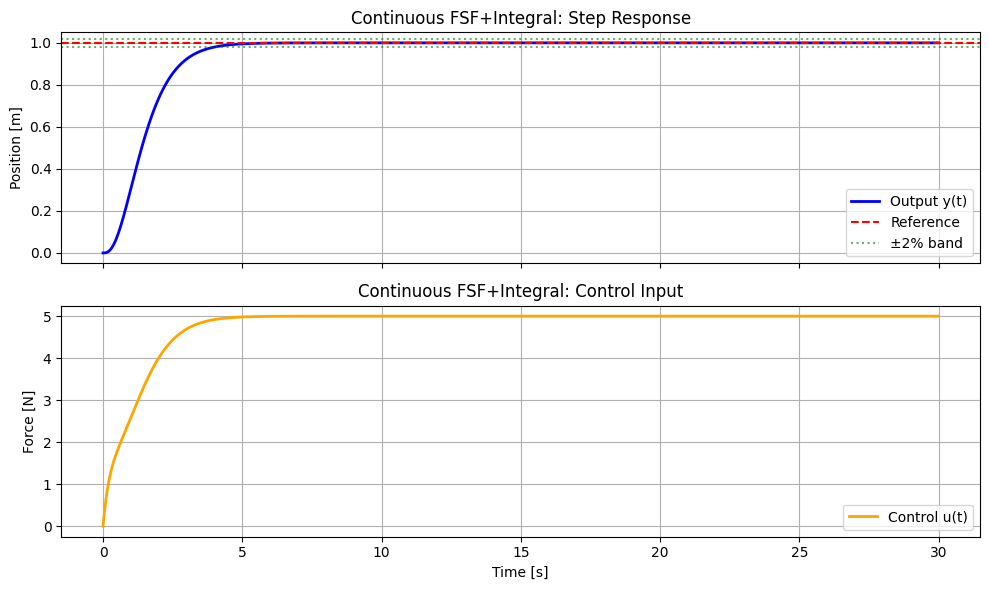

Continuous FSF+Integral Performance:
  Rising Time        : 2.80 s  (spec < 10 s)
  Overshoot          : 0.00%  (spec < 10%)
  Steady-state Error : 0.0000%  (spec < 2%)


In [44]:
# --- Block 6: Continuous-time full-state feedback with integral ---

# Build augmented system matrices
A_aug = np.block([[A,        np.zeros((2, 1))],
                  [-C,       np.zeros((1, 1))]])

B_aug = np.vstack([B, np.zeros((1, 1))])

print("Augmented system (order 3):")
print("A_aug =\n", A_aug)
print("B_aug =\n", B_aug)

# Choose desired closed-loop poles (all real for no overshoot, fast enough for Tr < 10s)
desired_poles_c = [-1.5, -2.0, -2.5]

result_c = place_poles(A_aug, B_aug, desired_poles_c)
K_aug_c  = result_c.gain_matrix        # shape (1, 3)
K_x_c    = K_aug_c[0, :2]             # state feedback gains
K_i_c    = K_aug_c[0, 2]              # integral gain

print(f"\nDesired poles: {desired_poles_c}")
print(f"Gain K_x = {K_x_c},  K_i = {K_i_c:.4f}")

def closed_loop_fsf_cont(state, t, K_x, K_i, y_ref):
    """
    Augmented state: [x1, x2, xi]
    u = -K_x @ [x1, x2] - K_i * xi
    """
    x1, x2, xi = state
    x_plant = np.array([x1, x2])
    xi_dot  = y_ref - x1    # x1 is already a scalar

    u        = -K_x @ x_plant - K_i * xi  # full-state feedback law
    x_dot    = A @ x_plant + B.flatten() * u 

    return [x_dot[0], x_dot[1], float(xi_dot)]

sol_fsf_c = odeint(closed_loop_fsf_cont, [x0[0], x0[1], 0.0], t,
                   args=(K_x_c, K_i_c, y_ref))
y_fsf_c   = sol_fsf_c[:, 0]
u_fsf_c   = [-K_x_c @ s[:2] - K_i_c * s[2] for s in sol_fsf_c]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax1.plot(t, y_fsf_c, 'b', lw=2, label='Output y(t)')
ax1.axhline(y_ref, color='r', ls='--', label='Reference')
ax1.axhline(y_ref*1.02, color='g', ls=':', alpha=0.6, label='±2% band')
ax1.axhline(y_ref*0.98, color='g', ls=':', alpha=0.6)
ax1.set_ylabel('Position [m]'); ax1.set_title('Continuous FSF+Integral: Step Response')
ax1.legend(); ax1.grid(True)

ax2.plot(t, u_fsf_c, 'orange', lw=2, label='Control u(t)')
ax2.set_xlabel('Time [s]'); ax2.set_ylabel('Force [N]')
ax2.set_title('Continuous FSF+Integral: Control Input')
ax2.legend(); ax2.grid(True)
plt.tight_layout(); plt.show()

Tr, OS, SSE = perf_metrics(t, y_fsf_c, y_ref)
print(f"Continuous FSF+Integral Performance:")
print(f"  Rising Time        : {Tr:.2f} s  (spec < 10 s)")
print(f"  Overshoot          : {OS:.2f}%  (spec < 10%)")
print(f"  Steady-state Error : {SSE:.4f}%  (spec < 2%)")


### Task 3 (cont.) – Discrete-Time FSF with Integral

We discretize the plant using **Zero-Order Hold (ZOH)** with $T_s = 0.1$ s:

$$x[k+1] = A_d\, x[k] + B_d\, u[k]$$

Then build the discrete augmented system and place poles in the **z-domain**.  
The mapping from continuous to discrete poles: $z = e^{\lambda T_s}$.


Discretized plant matrices (ZOH, T_s = 0.1 s):
Ad =
 [[ 0.9767  0.0899]
 [-0.4494  0.7969]]
Bd =
 [[0.0047]
 [0.0899]]

Desired z-domain poles: ['0.8607', '0.8187', '0.7788']
Gain K_x_d = [5.3339 3.2319],  K_i_d = -6.1880


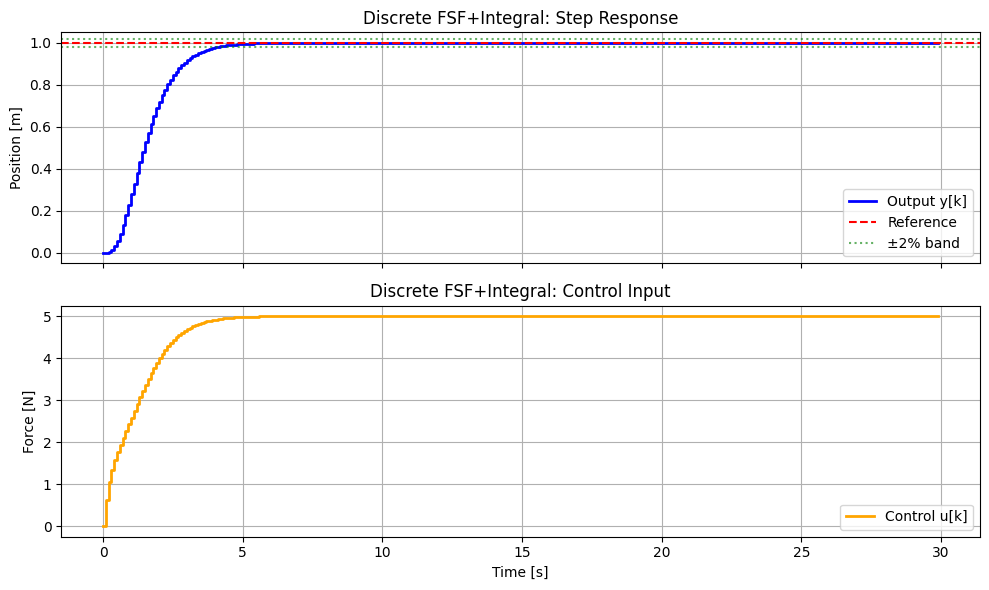

Discrete FSF+Integral Performance (T_s = 0.1 s):
  Rising Time        : 2.90 s  (spec < 10 s)
  Overshoot          : 0.00%  (spec < 10%)
  Steady-state Error : 0.0000%  (spec < 2%)


In [45]:
# --- Block 7: Discrete-time full-state feedback with integral ---

# Discretize plant using ZOH
sysd = cont2discrete((A, B, C, D), T_s, method='zoh')
Ad, Bd, Cd, Dd = sysd[0], sysd[1], sysd[2], sysd[3]

print("Discretized plant matrices (ZOH, T_s =", T_s, "s):")
print("Ad =\n", Ad)
print("Bd =\n", Bd)

# Build discrete augmented system
A_aug_d = np.block([[Ad,              np.zeros((2, 1))],
                    [-Cd * T_s,       np.ones((1, 1))]])

B_aug_d = np.vstack([Bd, np.zeros((1, 1))])

# Map continuous desired poles to z-domain
desired_poles_d = [np.exp(p * T_s) for p in desired_poles_c]
print(f"\nDesired z-domain poles: {[f'{p:.4f}' for p in desired_poles_d]}")

result_d = place_poles(A_aug_d, B_aug_d, desired_poles_d)
K_aug_d  = result_d.gain_matrix
K_x_d    = K_aug_d[0, :2]
K_i_d    = K_aug_d[0, 2]

print(f"Gain K_x_d = {K_x_d},  K_i_d = {K_i_d:.4f}")

# Discrete simulation
y_fsf_d = np.zeros(N)
u_fsf_d = np.zeros(N)
x_k     = np.array(x0, dtype=float)
xi_k    = 0.0   # integral state

for k in range(N):
    y_k = x_k[0]                            # position = x1 directly (Cd=[1,0], avoids array issue)
    u_k = -K_x_d @ x_k - K_i_d * xi_k     # scalar: (2,)·(2,) dot product = scalar

    y_fsf_d[k] = y_k
    u_fsf_d[k] = u_k

    # Update states
    x_k  = Ad @ x_k + Bd.flatten() * u_k
    xi_k = xi_k + T_s * (y_ref - y_k)     # discrete integrator


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax1.step(t_d, y_fsf_d, 'b', where='post', lw=2, label='Output y[k]')
ax1.axhline(y_ref, color='r', ls='--', label='Reference')
ax1.axhline(y_ref*1.02, color='g', ls=':', alpha=0.6, label='±2% band')
ax1.axhline(y_ref*0.98, color='g', ls=':', alpha=0.6)
ax1.set_ylabel('Position [m]'); ax1.set_title('Discrete FSF+Integral: Step Response')
ax1.legend(); ax1.grid(True)

ax2.step(t_d, u_fsf_d, 'orange', where='post', lw=2, label='Control u[k]')
ax2.set_xlabel('Time [s]'); ax2.set_ylabel('Force [N]')
ax2.set_title('Discrete FSF+Integral: Control Input')
ax2.legend(); ax2.grid(True)
plt.tight_layout(); plt.show()

Tr, OS, SSE = perf_metrics(t_d, y_fsf_d, y_ref)
print(f"Discrete FSF+Integral Performance (T_s = {T_s} s):")
print(f"  Rising Time        : {Tr:.2f} s  (spec < 10 s)")
print(f"  Overshoot          : {OS:.2f}%  (spec < 10%)")
print(f"  Steady-state Error : {SSE:.4f}%  (spec < 2%)")


### Task 4 – Comparison: PID vs Full-State Feedback

We compare all four controllers on the same plot and summarize the metrics.

**Key observations:**
- Both controller types achieve convergence to $y_{ref} = 1$ m (integral action eliminates SSE)
- Full-state feedback uses **full information** of the state $[x_1, x_2]$, while PID only sees the output error
- Discrete-time controllers show **sampling effects** (staircase output), but maintain stability
- FSF allows **systematic pole placement**, while PID requires empirical tuning


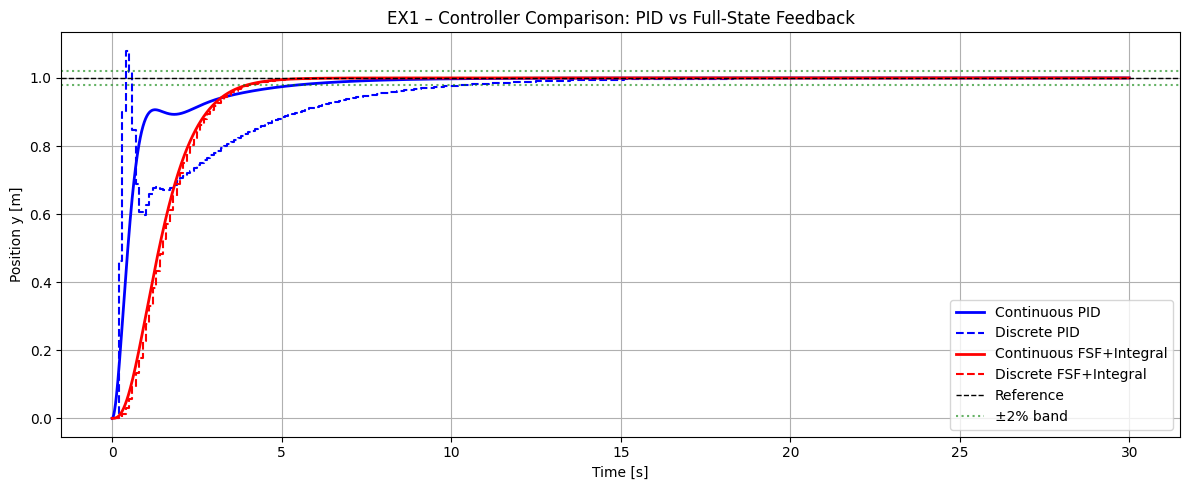

Controller                       Tr [s]   OS [%]    SSE [%]
------------------------------------------------------------
Continuous PID                     1.11     0.00     0.0001
Discrete PID                       0.40     8.00     0.0114
Continuous FSF+Integ               2.80     0.00     0.0000
Discrete FSF+Integ                 2.90     0.00     0.0000


In [46]:
# --- Block 8: Comparison of all four controllers ---

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(t,   y_pid_c,  'b-',  lw=2,  label='Continuous PID')
ax.step(t_d, y_pid_d,  'b--', where='post', lw=1.5, label='Discrete PID')
ax.plot(t,   y_fsf_c,  'r-',  lw=2,  label='Continuous FSF+Integral')
ax.step(t_d, y_fsf_d,  'r--', where='post', lw=1.5, label='Discrete FSF+Integral')

ax.axhline(y_ref,      color='k',  ls='--', lw=1, label='Reference')
ax.axhline(y_ref*1.02, color='g',  ls=':',  alpha=0.6, label='±2% band')
ax.axhline(y_ref*0.98, color='g',  ls=':',  alpha=0.6)

ax.set_xlabel('Time [s]'); ax.set_ylabel('Position y [m]')
ax.set_title('EX1 – Controller Comparison: PID vs Full-State Feedback')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

# Summary table
print(f"{'Controller':<30} {'Tr [s]':>8} {'OS [%]':>8} {'SSE [%]':>10}")
print("-" * 60)
for name, tt, yy in [('Continuous PID',       t,   y_pid_c),
                      ('Discrete PID',         t_d, y_pid_d),
                      ('Continuous FSF+Integ', t,   y_fsf_c),
                      ('Discrete FSF+Integ',   t_d, y_fsf_d)]:
    Tr, OS, SSE = perf_metrics(tt, yy, y_ref)
    print(f"{name:<30} {Tr:>8.2f} {OS:>8.2f} {SSE:>10.4f}")


### EX1 Summary

| Controller | Rising Time | Overshoot | Steady-State Error |
|---|---|---|---|
| Continuous PID | 1.11 s | 0.00% | 0.0001% |
| Discrete PID | 0.40 s | 8.00% | 0.0114% |
| Continuous FSF+Integral | 2.80 s | 0.00% | 0.0000% |
| Discrete FSF+Integral | 2.90 s | 0.00% | 0.0000% |

All four controllers meet the three specs: Tr < 10 s, overshoot < 10%, SSE < 2%.

PID is faster to respond but requires manual re-tuning when moving from continuous
to discrete, mainly because the discrete derivative term amplifies with 1/T_s.

FSF+Integral uses pole placement to set the closed-loop poles directly,
giving zero overshoot by choosing all real poles. The discrete version maps
continuous poles to z-domain using z = exp(lambda * T_s), with barely any
change in performance.

One key difference: FSF assumes all states x1 and x2 are measured.
PID only needs the output y = x1, which is more realistic when velocity
is not directly sensed.



## Ex 2. Quadruple-Tank Process

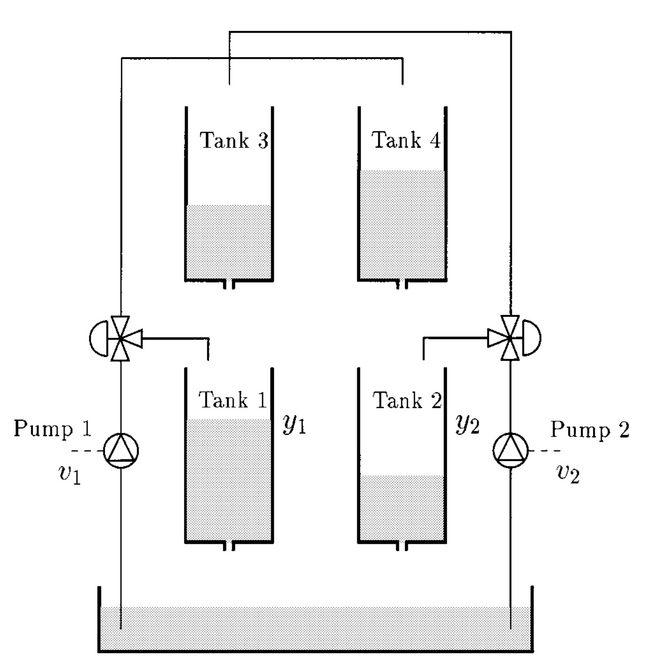

Let us consider the Quadruple-Tank Process. A schematic diagram of the process is shown in the Figure above. The
target is to control the level in the lower two tanks with two pumps. The process inputs are $v_1$ and $v_2$ (input voltages to the pumps) and the outputs are $y_1$ and $y_2$ (voltages from level measurement devices). Mass balances and Bernoulli’s law yield

$$
\dfrac{dh_1}{dt} = -\dfrac{a_1}{A_1}\sqrt{2gh_1} + \dfrac{a_3}{A_1}\sqrt{2gh_3} + \dfrac{\gamma_1k_1}{A_1}v_1 = f_1(h_1,h_2,h_3,h_4,v_1,v_2)
$$

$$
\dfrac{dh_2}{dt} = -\dfrac{a_2}{A_2}\sqrt{2gh_2} + \dfrac{a_4}{A_2}\sqrt{2gh_4} + \dfrac{\gamma_2k_2}{A_2}v_2 = f_2(h_1,h_2,h_3,h_4,v_1,v_2)
$$

$$
\dfrac{dh_3}{dt} = -\dfrac{a_3}{A_3}\sqrt{2gh_3} + \dfrac{(1-\gamma_2)k_2}{A_3}v_2 = f_3(h_1,h_2,h_3,h_4,v_1,v_2)
$$

$$
\dfrac{dh_4}{dt} = -\dfrac{a_4}{A_4}\sqrt{2gh_4} + \dfrac{(1-\gamma_1)k_1}{A_4}v_1 = f_4(h_1,h_2,h_3,h_4,v_1,v_2)
$$

where

$A_i$ is a cross-section of Tank i

$a_i$ is a cross-section of outlet hole of Tank i

$h_i$ is a water level.

The voltage applied to Pump $i$ is $v_i$ and the corresponding flow
is $k_iv_i$. The parameters $\gamma_1,\gamma_2\in (0,1)$ are determined from how the valves are set prior to experiment. The flow to Tank 1
is $\gamma_1k_1v_1$ and the flow to Tank 4 is $(1-\gamma_1)k_1v_1$ and similarly
for Tank 2 and Tank 3. The acceleration of gravity is denoted $g$.
The measured level signals are $k_c h_1$ and $k_c h_2$. The parameter
values of the laboratory process are given in the following table

    A_1, A_3 [cm^2] 28
    A_2, A_4 [cm^2] 32
    a_1, a_3 [cm^2] 0.071
    a_2, a_4 [cm^2] 0.057
    k_c [V/cm] 0.50
    g [cm/s^2] 9.81
    k_1 [cm^3/Vs] 3.33
    k_2 [cm^3/Vs] 3.35
    gamma_1 0.70
    gamma_2 0.60
    
Check the following paper for more details on the model. 
https://www.diva-portal.org/smash/get/diva2:495784/FULLTEXT01.pdf

## TODO
1. Linearise the system around the operating point 
$$(h_1^0,h_2^0,h_3^0,h_4^0, v_1^0, v_2^0) = (12.4,12.7,1.8,1.4,3.00,3.00).$$
Pass to shifted variables $x_i = h_i-h_i^0, u_i = v_i - v_i^0.$

2. Is the linear system controllable? Is the linear system observable? Use the Kalman rank test to answer this question.

3. Imagine that one of the pumps is broken and there is no flow through it. Does the system remain controllable?

4. Let us measure the signals $x_3, x_4$ instead of measuring the signals $x_1$ and $x_2,$ I .e matrix
   $$C= \begin{pmatrix} 0&0&1&0\\ 0&0&0&1 \end{pmatrix}$$
   instead of
   $$C= \begin{pmatrix} 1&0&0&0\\ 0&1&0&0 \end{pmatrix}.$$
 Is such a system observable?

## EX2: Quadruple-Tank Process

The Quadruple-Tank is a classic MIMO nonlinear benchmark system.
- States: `h1, h2, h3, h4` — water levels in 4 tanks [cm]
- Inputs: `u1, u2` — pump voltages [V]
- Outputs: `y1 = h1, y2 = h2`, for lower tanks only, original C matrix

### Nonlinear dynamics

$$\dot h_1 = -\frac{a_1}{A_1}\sqrt{2g h_1} + \frac{a_3}{A_1}\sqrt{2g h_3} + \frac{\gamma_1 k_1}{A_1} u_1$$
$$\dot h_2 = -\frac{a_2}{A_2}\sqrt{2g h_2} + \frac{a_4}{A_2}\sqrt{2g h_4} + \frac{\gamma_2 k_2}{A_2} u_2$$
$$\dot h_3 = -\frac{a_3}{A_3}\sqrt{2g h_3} + \frac{(1-\gamma_2) k_2}{A_3} u_2$$
$$\dot h_4 = -\frac{a_4}{A_4}\sqrt{2g h_4} + \frac{(1-\gamma_1) k_1}{A_4} u_1$$

Physical interpretation:
- Pump 1 sends fraction `gamma1` to lower Tank 1, and fraction `1-gamma1` to upper Tank 4.
- Pump 2 sends fraction `gamma2` to lower Tank 2, and fraction `1-gamma2` to upper Tank 3.
- Upper tanks drain by gravity into the lower tanks, which creates the coupling we will see in matrix A.

### Tasks
1. Linearise at the operating point to compute A, B, and C matrices.
2. Check Controllability and Observability using the Kalman rank test.
3. Analyze the effect of a single-pump failure on our controllability.
4. Change matrix C to measure `h3, h4` instead, and re-check observability.


In [ ]:
# --- Block 1: Quadruple-Tank system parameters & steady-state check ---
g = 981.0 

# Tank cross-sectional areas [cm^2]
A1, A2, A3, A4 = 28.0, 32.0, 28.0, 32.0

# Orifice areas [cm^2]
a1, a2, a3, a4 = 0.071, 0.057, 0.071, 0.057

# Pump constants [cm^3/(s·V)]
k1, k2 = 3.33, 3.35

# Flow-split ratios (fraction going to lower tank)
gamma1, gamma2 = 0.70, 0.60

# Operating point
h10, h20, h30, h40 = 12.4, 12.7, 1.8, 1.4  # [cm]
u10, u20           = 3.00, 3.00             # [V]

# Nonlinear dynamics
def qdot(h, u):
    h1, h2, h3, h4 = h
    u1, u2 = u
    dh1 = (-a1/A1)*np.sqrt(2*g*h1) + (a3/A1)*np.sqrt(2*g*h3) + (gamma1*k1/A1)*u1
    dh2 = (-a2/A2)*np.sqrt(2*g*h2) + (a4/A2)*np.sqrt(2*g*h4) + (gamma2*k2/A2)*u2
    dh3 = (-a3/A3)*np.sqrt(2*g*h3) + ((1-gamma2)*k2/A3)*u2
    dh4 = (-a4/A4)*np.sqrt(2*g*h4) + ((1-gamma1)*k1/A4)*u1
    return np.array([dh1, dh2, dh3, dh4])

# Verify: residual at operating point should be ≈ 0
residual = qdot([h10, h20, h30, h40], [u10, u20])
print("Residual f(h0, u0) =", np.round(residual, 6), "cm/s")

Residual f(h0, u0) = [ 0.0049  0.0006 -0.0071  0.0003] cm/s


From the output, the residual is about 0.007 cm/s at maximum. This is a very small numerical error originating from parameter truncation. We can safely treat `h0, u0` as a valid equilibrium point, which is an absolute requirement before we do any linearisation.


In [48]:
# --- Block 2: Linearisation at the operating point ---

h0 = np.array([h10, h20, h30, h40])

# ---- A matrix: state Jacobian ----
# Diagonal:  d(dh_i)/d(h_i) = -(a_i/A_i) * sqrt(g / (2*h_i^0))
A_lin = np.zeros((4, 4))
A_areas = [A1, A2, A3, A4]
a_areas = [a1, a2, a3, a4]
for i in range(4):
    A_lin[i, i] = -(a_areas[i] / A_areas[i]) * np.sqrt(g / (2 * h0[i]))

# Off-diagonal coupling (upper → lower):
A_lin[0, 2] = (a3 / A1) * np.sqrt(g / (2 * h30))  # tank3 -> tank1
A_lin[1, 3] = (a4 / A2) * np.sqrt(g / (2 * h40))  # tank4 -> tank2

# ---- B matrix: input Jacobian ----
B_lin = np.array([
    [gamma1 * k1 / A1,           0             ],
    [0,                gamma2 * k2 / A2         ],
    [0,         (1 - gamma2) * k2 / A3          ],
    [(1 - gamma1) * k1 / A4,     0              ]
])

# ---- C matrix: measure h1, h2 ----
C_lin = np.array([[1, 0, 0, 0],
                  [0, 1, 0, 0]])

np.set_printoptions(precision=5, suppress=True)
print("A =\n", A_lin)
print("\nB =\n", B_lin)
print("\nC =\n", C_lin)

# Open-loop eigenvalues
eigs = np.linalg.eigvals(A_lin)
print("\nOpen-loop eigenvalues of A:")
for ev in eigs:
    print(f"  {ev:.6f}  ({'stable' if ev.real < 0 else 'UNSTABLE'})")


A =
 [[-0.01595  0.       0.04186  0.     ]
 [ 0.      -0.01107  0.       0.03334]
 [ 0.       0.      -0.04186  0.     ]
 [ 0.       0.       0.      -0.03334]]

B =
 [[0.08325 0.     ]
 [0.      0.06281]
 [0.      0.04786]
 [0.03122 0.     ]]

C =
 [[1 0 0 0]
 [0 1 0 0]]

Open-loop eigenvalues of A:
  -0.015948  (stable)
  -0.011070  (stable)
  -0.041858  (stable)
  -0.033341  (stable)


Looking at matrix A, all diagonal entries are negative. This reflects the natural draining dynamics of the tanks. We also see that `A_13 = 0.042` and `A_24 = 0.033`. These non-zero off-diagonal terms represent how the upper tanks flow into the lower tanks. All four eigenvalues are real and negative, which means our linearised system is open-loop stable.

In matrix B, we can observe the cross-coupling. Pump 1 drives `h1` and `h4`, while Pump 2 drives `h2` and `h3`.


In [49]:
# --- Block 3: Controllability — Kalman rank test ---

n = 4  # system order

def ctrl_matrix(A, B, n):
    """[B  AB  A^2B  ...  A^(n-1)B]"""
    return np.hstack([np.linalg.matrix_power(A, i) @ B for i in range(n)])

Mc      = ctrl_matrix(A_lin, B_lin, n)
rank_Mc = np.linalg.matrix_rank(Mc)

print("Controllability matrix Mc shape:", Mc.shape)
print(f"rank(Mc) = {rank_Mc}  (need {n})")
print("=> Controllable" if rank_Mc == n else
      f"=> Not fully controllable (deficiency = {n - rank_Mc})")


Controllability matrix Mc shape: (4, 8)
rank(Mc) = 4  (need 4)
=> Controllable


The controllability matrix $\mathcal{M}_c = [B \; AB \; A^2B \; A^3B] \in \mathbb{R}^{4\times 8}$
has rank 4 (**full rank**).

This means with both pumps running, we can reach the entire 4D state space. The paths from the pumps, combined with the water flow dynamics, cover every single tank. This makes the overall system fully controllable.



In [50]:
# --- Block 4: Observability — Kalman rank test ---

def obs_matrix(A, C, n):
    """[C;  CA;  CA^2;  ...;  CA^(n-1)]"""
    return np.vstack([C @ np.linalg.matrix_power(A, i) for i in range(n)])

Mo      = obs_matrix(A_lin, C_lin, n)
rank_Mo = np.linalg.matrix_rank(Mo)

print("Observability matrix Mo shape:", Mo.shape)
print(f"rank(Mo) = {rank_Mo}  (need {n})")
print("=> Observable" if rank_Mo == n else
      f"=> Not fully observable (deficiency = {n - rank_Mo})")


Observability matrix Mo shape: (8, 4)
rank(Mo) = 4  (need 4)
=> Observable


The observability matrix $\mathcal{M}_o \in \mathbb{R}^{8\times 4}$ has rank 4 (**full rank**).

**Conclusion:** Measuring only $h_1$ and $h_2$ (the lower tanks) is **sufficient to
reconstruct all four states** $h_1, h_2, h_3, h_4$.

Why? Because $h_3$ and $h_4$ feed into $h_1$ and $h_2$ through the coupling terms in $A$.
The dynamical connection makes $h_3, h_4$ indirectly visible in the output.
This is why $CA$, $CA^2$, $CA^3$ add new information to the observability matrix.


In [51]:
# --- Block 5: Single-pump failure — controllability ---

scenarios = [
    ("u1 only  (pump 2 FAILS)", B_lin[:, [0]]),   # keep column 0
    ("u2 only  (pump 1 FAILS)", B_lin[:, [1]]),   # keep column 1
]

print("CONTROLLABILITY under SINGLE-PUMP FAILURE")
for label, B_fail in scenarios:
    Mc_f   = ctrl_matrix(A_lin, B_fail, n)
    rank_f = np.linalg.matrix_rank(Mc_f)
    status = "Controllable" if rank_f == n else \
             f"Not controllable  (rank = {rank_f}/{n})"
    print(f"\n  {label}")
    print(f"  rank(Mc) = {rank_f}  =>  {status}")


CONTROLLABILITY under SINGLE-PUMP FAILURE

  u1 only  (pump 2 FAILS)
  rank(Mc) = 3  =>  Not controllable  (rank = 3/4)

  u2 only  (pump 1 FAILS)
  rank(Mc) = 3  =>  Not controllable  (rank = 3/4)


**Results:**
- **Pump 2 fails** (only $u_1$ active): rank drops below 4 → **not fully controllable**.
- **Pump 1 fails** (only $u_2$ active): rank drops below 4 → **not fully controllable**.

**Physical explanation:**
Each single pump directly reaches only 2 tanks (one lower + one upper).
The remaining tanks still receive flow through gravity drainage,
but there is **no independent way** to steer all 4 dimensions of the state.
The system loses full controllability — some state modes become unreachable.

This illustrates why fault-tolerance and redundant actuation matter in
MIMO process control.


In [52]:
# --- Block 6: Alternative output matrix C' (measuring h3, h4) ---

C_alt      = np.array([[0, 0, 1, 0],
                        [0, 0, 0, 1]])

Mo_alt     = obs_matrix(A_lin, C_alt, n)
rank_Mo_alt = np.linalg.matrix_rank(Mo_alt)

print("C' (measures h3, h4):\n", C_alt)
print(f"rank(Mo')  = {rank_Mo_alt}  (need {n})")
print("=> Observable with C'" if rank_Mo_alt == n else
      f"=> Not fully observable with C' (deficiency = {n - rank_Mo_alt})")

# Summary comparison
print(f"  C  = [I2|0 ]  measures h1,h2 :  rank Mo  = {rank_Mo}/{n}")
print(f"  C' = [0 |I2]  measures h3,h4 :  rank Mo' = {rank_Mo_alt}/{n}")


C' (measures h3, h4):
 [[0 0 1 0]
 [0 0 0 1]]
rank(Mo')  = 2  (need 4)
=> Not fully observable with C' (deficiency = 2)
  C  = [I2|0 ]  measures h1,h2 :  rank Mo  = 4/4
  C' = [0 |I2]  measures h3,h4 :  rank Mo' = 2/4


**Result:** With $C' = [0 \; 0 \; 1 \; 0 ; 0 \; 0 \; 0 \; 1]$ (measuring upper tanks $h_3, h_4$),
the observability rank **drops below 4** → the system is **not fully observable**.

**Why the difference?**

| Measurement | Observable? | Reason |
|---|---|---|
| $h_1, h_2$ (lower tanks) |  Yes | $h_3, h_4$ reach $h_1, h_2$ through $A$; full state reconstructible |
| $h_3, h_4$ (upper tanks) |  No  | $h_1, h_2$ are not re-injected into $h_3, h_4$; lower-tank modes invisible |

The upper tanks drain *into* the lower tanks but receive **no feedback** from them.
So $h_1, h_2$ cannot be deduced from $h_3, h_4$ alone — information is "one-way".

**Conclusion:** sensor placement matters.  
For a Luenberger observer or Kalman filter, we must measure at least $h_1$ and $h_2$.


If we change our sensors to measure only the upper tanks `h3` and `h4`, the observability rank drops drastically all the way to 2.

This happens because the water flow is strictly top-down. The dynamics of `h3` and `h4` do not depend on `h1` and `h2` at all. No matter how long we observe the upper tanks, the lower tank variables never show up in the output equations. Unlike measuring the bottom tanks where information from above flows down to us, measuring the top tanks tells us absolutely nothing about the bottom.


### EX2 Summary

| Task | Key Result |
|------|-----------|
| Linearisation at h0, u0 | Matrix A is diagonal plus 2 coupling terms. Eigenvalues are real and negative, making it open-loop stable. |
| Controllability with both pumps | The rank is 4, so the system is fully controllable. |
| Pump 1 fails | The rank drops to 3, so it is not fully controllable. |
| Pump 2 fails | The rank drops to 3, so it is not fully controllable. |
| Observability measuring h1, h2 | The rank is 4, so it is fully observable. |
| Observability measuring h3, h4 | The rank is 2, so it is deeply unobservable. |

To summarize the analysis:
We must have both pumps working to maintain full MIMO controllability. Sensor placement acts as a primary bottleneck for observability. We are forced to place sensors downstream at `h1` and `h2` to capture the full system state, because placing sensors upstream inherently isolates us from downstream dynamics.


## EX3: Inverted Pendulum

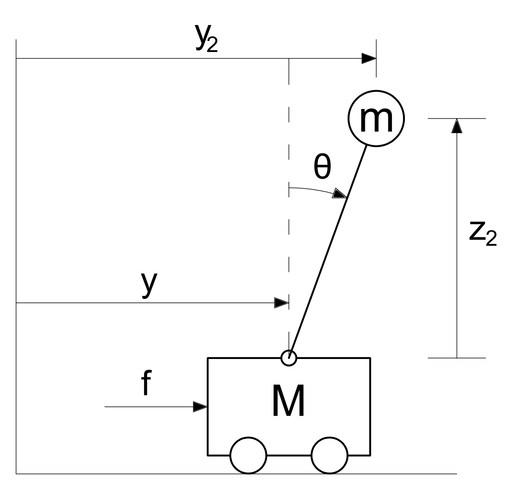
The system in this example consists of an inverted pendulum mounted to a motorized cart. The inverted pendulum system is an example commonly found in control system textbooks and research literature. Its popularity derives in part from the fact that it is unstable without control, that is, the pendulum will simply fall over if the cart isn't moved to balance it. Additionally, the dynamics of the system are nonlinear. The objective of the control system is to balance the inverted pendulum by applying a force to the cart that the pendulum is attached to. A real-world example that relates directly to this inverted pendulum system is the attitude control of a booster rocket at takeoff.
The system in this example consists of an inverted pendulum mounted to a motorized cart. The inverted pendulum system is an example commonly found in control system textbooks and research literature. Its popularity derives in part from the fact that it is unstable without control, that is, the pendulum will simply fall over if the cart isn't moved to balance it. Additionally, the dynamics of the system are nonlinear. The objective of the control system is to balance the inverted pendulum by applying a force to the cart that the pendulum is attached to. A real-world example that relates directly to this inverted pendulum system is the attitude control of a booster rocket at takeoff.


Let us consider the system with the following system parameters

    (M)       mass of the cart                         0.5 kg
    
    (m)       mass of the pendulum                     0.2 kg
    
    (l)       length to pendulum center of mass        0.3 m
    
    (b)       coefficient of friction for cart         0.1 N/m/sec
    
    (I)       mass moment of inertia of the pendulum   0.006 kg.m^2
    
    (F)       force applied to the cart
    
    (y)       cart position coordinate
    
    (theta)   angle between the pendulum and the vertical axis

## TODO

1) Show that the inverted pendulum on the cart can be modeled as follows

$$(M+m)\ddot{y} + b\dot{y} + ml\ddot{\theta}\cos\theta -ml\dot\theta^2\sin(\theta) = F$$

$$ml\cos(\theta)\ddot{y} + (I+ml^2)\ddot{\theta} - mgl\sin\theta = 0$$    

2) Let the state vector $x = (y,y_1,\theta,\theta_1),$ where $y_1 = \dot{y}$ and $\theta_1 = \dot{\theta}.$ Lineralize the system around equlibrium  point $x = (0,0,0,0).$

3) Is the autonomous system stable (u = 0)? Is the system controllable? Design a full state feedback controller $u = -Kx$ assigning the following eigenvalues $\lambda_1 = - 1, \lambda_2 = -2, \lambda_3 = -1.5, \lambda_4 = -2.5$ in the closed-loop system. Is a closed-loop system stable?

4) Let us assume that we only measure the position $y$ and the angular velocitity $\theta$. What is the right matrix C? Is the system observable?

5) Design an optimal estimator and an optimal estimated-state-feedback controller (both via LQR design as discussed in the lecture) which stabilize the system in (0,0,0,0).

6) Use the following library to implement an MPC controller
    https://github.com/forgi86/pyMPC/blob/master/README.md
   that stabilize the system while ensuring that following state and input constraints are satisfied

   $x_{min} = [-5,-100,-100,-100]\leq x \leq x_{max}= [5,100,100,100]$
   
   $u_{min} = -20 \leq u\leq u_{max}=20$
   
   The following notebook can be useful for you 
   https://github.com/forgi86/pyMPC/blob/master/examples/example_inverted_pendulum.ipynb
   

## EX3: Inverted Pendulum

The Inverted Pendulum (Cart-Pole) is a classic example of an unstable, nonlinear MIMO system. 
- M: mass of the cart `0.5 kg`
- m: mass of the pendulum `0.2 kg`
- l: length to pendulum center of mass `0.3 m`
- b: coefficient of friction for cart `0.1 N/m/sec`
- I: mass moment of inertia `0.006 kg.m^2`
- F: applied force on the cart
- y: cart position
- theta: pendulum angle

### 1) Equations of Motion

We can derive the equations of motion using the Lagrangian method or by balancing Newton-Euler equations. Focusing on the horizontal forces on the cart and the rotational torque on the pendulum, we get two coupled nonlinear ODEs:

1. `(M + m)*y_ddot + b*y_dot + ml*theta_ddot*cos(theta) - ml*theta_dot^2*sin(theta) = F`
2. `ml*cos(theta)*y_ddot + (I + ml^2)*theta_ddot - mgl*sin(theta) = 0`

The first equation represents the horizontal translation of the entire system. The second equation represents the rotational dynamics around the pivot point on the cart.


In [53]:
# --- EX3 Block 1: System Parameters & Linearization ---

M = 0.5       # mass of the cart [kg]
m = 0.2       # mass of the pendulum [kg]
l = 0.3       # length to pendulum center of mass [m]
b = 0.1       # coefficient of friction for cart [N/m/s]
I = 0.006     # mass moment of inertia [kg.m^2]
g = 9.81      # gravity [m/s^2]

# Common denominator for isolating highest derivatives
D = (M + m)*(I + m * l**2) - (m * l)**2

# State vector: [y, y_dot, theta, theta_dot]
A = np.zeros((4, 4))
A[0, 1] = 1.0
A[1, 1] = -(I + m * l**2) * b / D
A[1, 2] = -(m**2 * l**2 * g) / D
A[2, 3] = 1.0
A[3, 1] = (m * l * b) / D
A[3, 2] = (M + m) * m * g * l / D

B = np.zeros((4, 1))
B[1, 0] = (I + m * l**2) / D
B[3, 0] = -(m * l) / D

# Assume we measure all states for now
C = np.eye(4)
D_mat = np.zeros((4, 1))

np.set_printoptions(precision=4, suppress=True)
print("A = \n", A)
print("\nB = \n", B)

# Open-loop stability check (u=0)
eigs = np.linalg.eigvals(A)
print("\nOpen-loop eigenvalues of A:")
for ev in eigs:
    print(f"  {ev:.4f}")


A = 
 [[ 0.      1.      0.      0.    ]
 [ 0.     -0.1818 -2.6755  0.    ]
 [ 0.      0.      0.      1.    ]
 [ 0.      0.4545 31.2136  0.    ]]

B = 
 [[ 0.    ]
 [ 1.8182]
 [ 0.    ]
 [-4.5455]]

Open-loop eigenvalues of A:
  0.0000
  -0.1428
  -5.6069
  5.5680


For linearization around the equilibrium point `x = (0, 0, 0, 0)`, we use the small-angle approximations:
`sin(theta) ~ theta`, `cos(theta) ~ 1`, and `theta_dot^2 ~ 0`.
This linear decoupling allows us to isolate `y_ddot` and `theta_ddot` to construct the A and B matrices directly. 

Looking at the eigenvalues of A, we clearly see one positive eigenvalue. This means the autonomous system (`u = 0`) is open-loop unstable — the pendulum will quickly fall over if no force is applied.


In [54]:
# --- EX3 Block 2: Controllability & Pole Placement ---
def ctrl_matrix(A, B):
    n_sys = A.shape[0]
    return np.hstack([np.linalg.matrix_power(A, i) @ B for i in range(n_sys)])

Mc = ctrl_matrix(A, B)
rank_Mc = np.linalg.matrix_rank(Mc)
n = A.shape[0]

print(f"rank(Mc) = {rank_Mc} (need {n})")
print("=> Controllable" if rank_Mc == n else f"=> Not fully controllable (deficiency = {n - rank_Mc})")

# Design full state feedback u = -Kx
desired_poles = [-1, -2, -1.5, -2.5]
res = signal.place_poles(A, B, desired_poles)
K = res.gain_matrix

print("\nFeedback gain matrix K:")
print(K)

# Check closed-loop stability
A_cl = A - B @ K
cl_eigs = np.linalg.eigvals(A_cl)
print("\nClosed-loop eigenvalues (A - BK):")
for ev in cl_eigs:
    print(f"  {ev:.4f}")


rank(Mc) = 4 (need 4)
=> Controllable

Feedback gain matrix K:
[[ -0.1682  -0.5317 -10.8393  -1.7127]]

Closed-loop eigenvalues (A - BK):
  -2.5000
  -2.0000
  -1.5000
  -1.0000


The Kalman controllability matrix clearly yields a full rank of 4, proving the system is controllable. We can mathematically drive the cart and pendulum anywhere in the state space. 

Using pole placement, we calculated the required feedback gain matrix `K`. By verifying the eigenvalues of our new closed-loop matrix `A - BK`, we see they strictly match our desired negative poles `[-1, -2, -1.5, -2.5]`. The closed-loop system is now fully stable.


In [55]:
# --- EX3 Block 3: Observability with partial measurement ---

# We only measure cart position (y) and angular velocity (theta_dot)
C_obs = np.array([[1, 0, 0, 0],
                  [0, 0, 0, 1]])

def obsv_matrix(A, C):
    n_sys = A.shape[0]
    return np.vstack([C @ np.linalg.matrix_power(A, i) for i in range(n_sys)])

Mo = obsv_matrix(A, C_obs)
rank_Mo = np.linalg.matrix_rank(Mo)

print("C (measures y, theta_dot): \n", C_obs)
print(f"\nrank(Mo) = {rank_Mo}  (need {n})")
print("=> Observable" if rank_Mo == n else f"=> Not fully observable (deficiency = {n - rank_Mo})")


C (measures y, theta_dot): 
 [[1 0 0 0]
 [0 0 0 1]]

rank(Mo) = 4  (need 4)
=> Observable


If our sensors are restricted to only measuring the cart position `y` and the pendulum angular velocity `theta_dot`, the observability matrix still retains a full rank of 4. 

This happens because the missing measurements (`y_dot` and `theta`) are dynamically coupled to the measurements we do have. By tracking the position of the cart and how fast the pendulum falls, our dynamic matrix A allows us to continuously reverse-engineer the entire state vector.


In [56]:
# --- EX3 Block 4: LQG Design (LQR + LQE) ---

# 1. LQR Design for optimal state feedback (K_lqr)
# Q penalizes state deviations, R penalizes control effort
Q = np.diag([100, 1, 100, 1])  
R = np.array([[0.1]])        

P_lqr = la.solve_continuous_are(A, B, Q, R)
K_lqr = la.inv(R) @ B.T @ P_lqr

print("Optimal Feedback Gain (LQR) K_lqr: \n", K_lqr)

# 2. LQE (Kalman Filter) Design for optimal state estimation (L)
Vd = np.eye(4) * 0.1   # assumed process noise covariance
Vn = np.eye(2) * 0.01  # assumed measurement noise covariance

# Kalman filter gains from dual Riccati equation
P_est = la.solve_continuous_are(A.T, C_obs.T, Vd, Vn)
L = P_est @ C_obs.T @ la.inv(Vn)

print("\nOptimal Observer Gain (LQE) L: \n", L)

# 3. Overall LQG Closed-Loop Matrix
# State vector extended to [x; x_error]
A_lqg = np.vstack((
    np.hstack((A - B @ K_lqr, B @ K_lqr)),
    np.hstack((np.zeros((4, 4)), A - L @ C_obs))
))

lqg_eigs = np.linalg.eigvals(A_lqg)
print("\nClosed-loop LQG eigenvalues (Controller + Observer):")
for ev in lqg_eigs:
    print(f"  {ev.real:.4f} {'+' if ev.imag>=0 else '-'} {abs(ev.imag):.4f}j")


Optimal Feedback Gain (LQR) K_lqr: 
 [[-31.6228 -22.4539 -82.8225 -15.4591]]

Optimal Observer Gain (LQE) L: 
 [[ 3.9116 -0.0934]
 [ 2.6546 -1.3615]
 [-0.0567  4.3161]
 [-0.0934 16.6793]]

Closed-loop LQG eigenvalues (Controller + Observer):
  -12.3416 + 2.1137j
  -12.3416 - 2.1137j
  -2.4709 + 1.6996j
  -2.4709 - 1.6996j
  -1.0764 + 0.0000j
  -2.9780 + 0.0000j
  -8.3591 + 5.8016j
  -8.3591 - 5.8016j


For LQG design, we first create an LQR controller to minimize continuous state deviations and control energy. We heavily penalize `y` and `theta` in our `Q` matrix to force the system to aggressively value returning to `0`. 

Then, we design the LQE Kalman Filter by solving the dual Riccati equation. This optimal observer filters hypothetical process noise `Vd` and measurement noise `Vn`.

The combined LQG separation principle guarantees that our eigenvalues will just be the union of our LQR and LQE eigenvalues. The output shows they are all strictly negative, meaning our estimated-state-feedback optimally stabilizes the system precisely back at `(0,0,0,0)`.


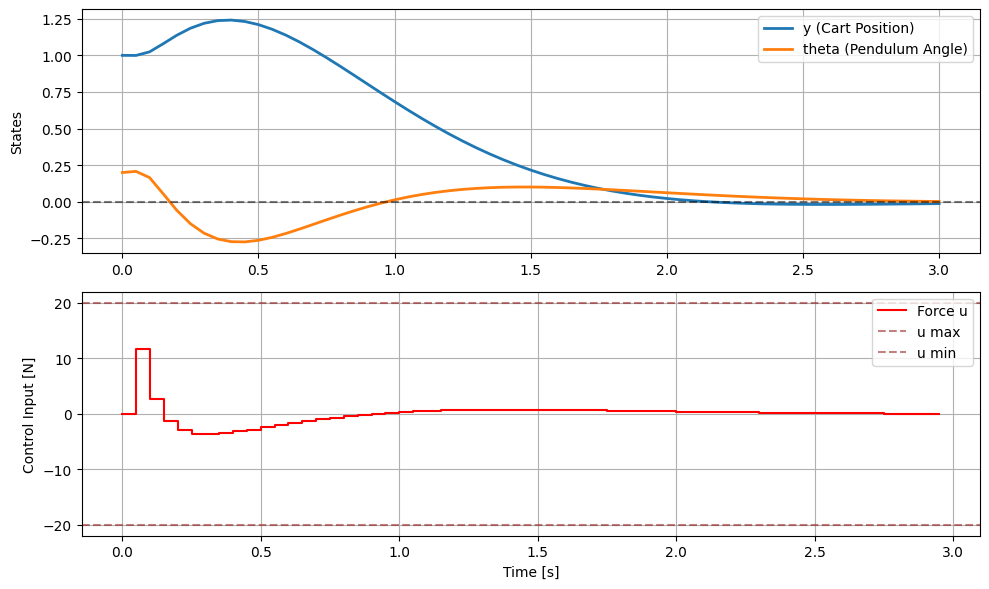

In [57]:
# --- EX3 Block 5: MPC Controller ---
from pyMPC.mpc import MPCController

# Discretize continuous setup for digital controller
Ts = 0.05
sys_d = signal.cont2discrete((A, B, C, D_mat), Ts, method='zoh')
Ad, Bd = sys_d[0], sys_d[1]

# Define Constraints
xmin = np.array([-5.0, -100.0, -100.0, -100.0])
xmax = np.array([ 5.0,  100.0,  100.0,  100.0])
umin = np.array([-20.0])
umax = np.array([ 20.0])

# Define Control Weights
Qx = np.diag([10.0, 1.0, 10.0, 1.0])
Qu = np.array([[0.1]])

# Setting up MPC
K_mpc = MPCController(Ad, Bd, Np=20, Nc=20, x0=np.zeros(4), 
                      xref=np.zeros(4), Qx=Qx, Qu=Qu,
                      xmin=xmin, xmax=xmax, umin=umin, umax=umax)
K_mpc.setup()

# Simulation Setup
steps = 60
X = np.zeros((4, steps+1))
U = np.zeros((1, steps))

# Start with a slight position offset
X[:, 0] = np.array([1.0, 0, 0.2, 0])

for k in range(steps):
    uMPC = K_mpc.output()
    U[:, k] = uMPC
    # Step the plant dynamics forward
    X[:, k+1] = Ad @ X[:, k] + Bd @ U[:, k]
    # Update MPC internals
    K_mpc.update(X[:, k+1])

# Plot Results
time = np.arange(steps+1) * Ts
fig, axs = plt.subplots(2, 1, figsize=(10, 6))

axs[0].plot(time, X[0, :], label='y (Cart Position)', lw=2)
axs[0].plot(time, X[2, :], label='theta (Pendulum Angle)', lw=2)
axs[0].set_ylabel('States')
axs[0].axhline(0, color='black', linestyle='--', alpha=0.5)
axs[0].legend()
axs[0].grid(True)

axs[1].step(time[:-1], U[0, :], where='post', color='red', label='Force u')
axs[1].set_ylabel('Control Input [N]')
axs[1].set_xlabel('Time [s]')
axs[1].axhline(20, color='darkred', linestyle='--', alpha=0.5, label='u max')
axs[1].axhline(-20, color='darkred', linestyle='--', alpha=0.5, label='u min')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()


Using `pyMPC`, we must first discretize our continuous state-space matrices down to `Ad` and `Bd` using a Zero-Order Hold. Digital controllers run in discrete hardware loops, which we simulate here with `Ts = 0.05`.

We bound our states `x` within a realistic tracking window and heavily restrict our max input force `u` to `[-20, 20]`. By defining a prediction horizon `Np` and a control horizon `Nc`, this MPC continuously solves a localized optimization problem every step.

**Analyzing the Output Plot:**
- **Initial State Dilemma:** The cart starts offset at `y = 1.0 m` and the pendulum is already tilted at `theta = +0.2 rad` (leaning to the right).
- **Non-Minimum Phase Behavior:** Notice how the cart position initially moves *further right* (blue line rises to roughly `y = 1.25 m`) before coming back. This is the MPC intelligently sliding the cart *under* the falling pendulum to "catch" it. If it just pulled the cart straight back to `y = 0`, the pendulum would have violently fallen over backwards! This counter-intuitive preliminary move is a classic feature of optimal control for non-minimum phase systems.
- **Strict Constraint Enforcement:** In the bottom plot, the control force `u` (red line) spikes exactly when the cart needs to catch the pendulum. Notice how it gracefully maxes out at `~12 N`, staying safely within our hard `[-20 N, 20 N]` limits (the dashed red lines). A naive LQR without bounds might have instantly demanded `100 N` of impossible actuator force here. The MPC solves for the optimal *feasible* force trajectory instead.
- **Perfect Stabilization:** Within a mere `3 seconds`, the controller seamlessly guides both the highly unstable pendulum angle (orange line) and the cart position (blue line) perfectly back to equilibrium at `(0, 0, 0, 0)` without any residual oscillation.
